In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

from copy import deepcopy

from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights

from sklearn.model_selection import train_test_split

from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
import os
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [8]:
label_index = {"dry": 0, "normal": 1, "oily": 2}
index_label = {0: "dry", 1: "normal", 2: "oily"}

In [9]:
def create_df(base):
    dd = {"images": [], "labels": []}
    for i in os.listdir(base):
        label = os.path.join(base, i)
        for j in os.listdir(label):
            img = os.path.join(label, j)
            dd["images"] += [img]
            dd["labels"] += [label_index[i]]
    return pd.DataFrame(dd)

# Creating dataset

In [10]:
train_df = create_df("/content/drive/MyDrive/skin-care/oily-dry-and-normal-skin-types-dataset/Oily-Dry-Skin-Types/train")
val_df = create_df("/content/drive/MyDrive/skin-care/oily-dry-and-normal-skin-types-dataset/Oily-Dry-Skin-Types/valid")
test_df = create_df("/content/drive/MyDrive/skin-care/oily-dry-and-normal-skin-types-dataset/Oily-Dry-Skin-Types/test")

In [11]:
train_df = pd.concat([train_df, val_df, test_df])

# Defining training parameters

In [12]:
EPOCHS = 20
LR = 0.1
STEP = 15
GAMMA = 0.1
BATCH = 32
OUT_CLASSES = 3
IMG_SIZE = 224

In [13]:
class CloudDS(Dataset):
    def __init__(self, data, transform):
        super(CloudDS, self).__init__()
        self.data = data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, x):
        img, label = self.data.iloc[x, 0], self.data.iloc[x, 1]
        img = Image.open(img).convert("RGB")
        img = self.transform(np.array(img))

        return img, label

In [14]:
train_transform = transforms.Compose([transforms.ToPILImage(),
                               transforms.ToTensor(),
                               transforms.Resize((IMG_SIZE, IMG_SIZE)),
                                transforms.RandomVerticalFlip(0.6),
                               transforms.Normalize(mean=[0.485, 0.456, 0.406],
                     std=[0.229, 0.224, 0.225])])

transform = transforms.Compose([transforms.ToPILImage(),
                               transforms.ToTensor(),
                               transforms.Resize((IMG_SIZE, IMG_SIZE)),
                               transforms.Normalize(mean=[0.485, 0.456, 0.406],
                     std=[0.229, 0.224, 0.225])])

In [15]:
train, testing = train_test_split(train_df, random_state=42, test_size=0.2)
val, test = train_test_split(testing, random_state=42, test_size=0.5)

In [16]:
train_ds = CloudDS(train, train_transform)
val_ds = CloudDS(val, transform)

In [17]:
train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=BATCH, shuffle=False)

# Downloading ResNet50

In [18]:
# resnet = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
# num_ftrs = resnet.fc.in_features
# resnet.fc.in_features = nn.Linear(num_ftrs, OUT_CLASSES)



from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import torch.nn as nn

# Load pre-trained EfficientNet with weights
resnet = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)

# Modify the final classifier to match your number of output classes
num_ftrs = resnet.classifier[1].in_features
resnet.classifier[1] = nn.Linear(num_ftrs, OUT_CLASSES)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 205MB/s]


In [19]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


# Training tools

In [20]:
import torch.nn as nn
from torchvision import models
from copy import deepcopy
# resnet = models.resnet50(pretrained=True)

# num_ftrs = resnet.fc.in_features
# resnet.fc = nn.Linear(num_ftrs,3)

model = deepcopy(resnet)
model = model.to(device)
# weights = torch.tensor([1.5, 1.0, 0.5]).cuda()  # penalize "dry" more, "normal" less

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=STEP, gamma=GAMMA)

# Training

In [22]:
best_model = deepcopy(model)
best_acc = 0

train_loss = []
train_acc = []
val_loss = []
val_acc = []

for i in range(1, EPOCHS+1):
    model.train()

    diff = 0
    total = 0
    acc = 0

    for data, target in train_dl:
        optimizer.zero_grad()
        if torch.cuda.is_available():
            data, target = data.cuda(), target.cuda()

        out = model(data)
        loss = criterion(out, target)
        diff += loss.item()
        acc += (out.argmax(1) == target).sum().item()
        total += out.size(0)
        loss.backward()
        optimizer.step()

    train_loss += [diff/total]
    train_acc += [acc/total]

    model.eval()

    diff = 0
    total = 0
    acc = 0

    with torch.no_grad():
        for data, target in val_dl:
            if torch.cuda.is_available():
                data, target = data.cuda(), target.cuda()

            out = model(data)
            loss = criterion(out, target)
            diff += loss.item()
            acc += (out.argmax(1) == target).sum().item()
            total += out.size(0)

    val_loss += [diff/total]
    val_acc += [acc/total]

    if val_acc[-1] > best_acc:
        best_acc = val_acc[-1]
        best_model = deepcopy(model)

    scheduler.step()

    print("Epochs {} train loss {} acc {} val loss {} acc {}".format(i, train_loss[-1],
                                                                    train_acc[-1], val_loss[-1],
                                                                    val_acc[-1]))

Epochs 1 train loss 0.031188631095568464 acc 0.4962316541055137 val loss 0.03205745712159172 acc 0.5206349206349207
Epochs 2 train loss 0.022955890545434586 acc 0.6790955969853233 val loss 0.029593227401612295 acc 0.5746031746031746
Epochs 3 train loss 0.01602028985904919 acc 0.7909559698532328 val loss 0.025994213422139485 acc 0.707936507936508
Epochs 4 train loss 0.011262885531656613 acc 0.8675128917096391 val loss 0.02421189830416725 acc 0.7111111111111111
Epochs 5 train loss 0.008358434640618839 acc 0.9012296707655693 val loss 0.022167675835745675 acc 0.7746031746031746
Epochs 6 train loss 0.005466862695084021 acc 0.9440698135660452 val loss 0.017713643634130083 acc 0.8253968253968254
Epochs 7 train loss 0.004513737479227018 acc 0.9468464894882983 val loss 0.022262170201256162 acc 0.7777777777777778
Epochs 8 train loss 0.004044895025264976 acc 0.9527965093216978 val loss 0.04460616414509122 acc 0.580952380952381
Epochs 9 train loss 0.0034260490612939253 acc 0.9615232050773502 val l

# Model's performance log

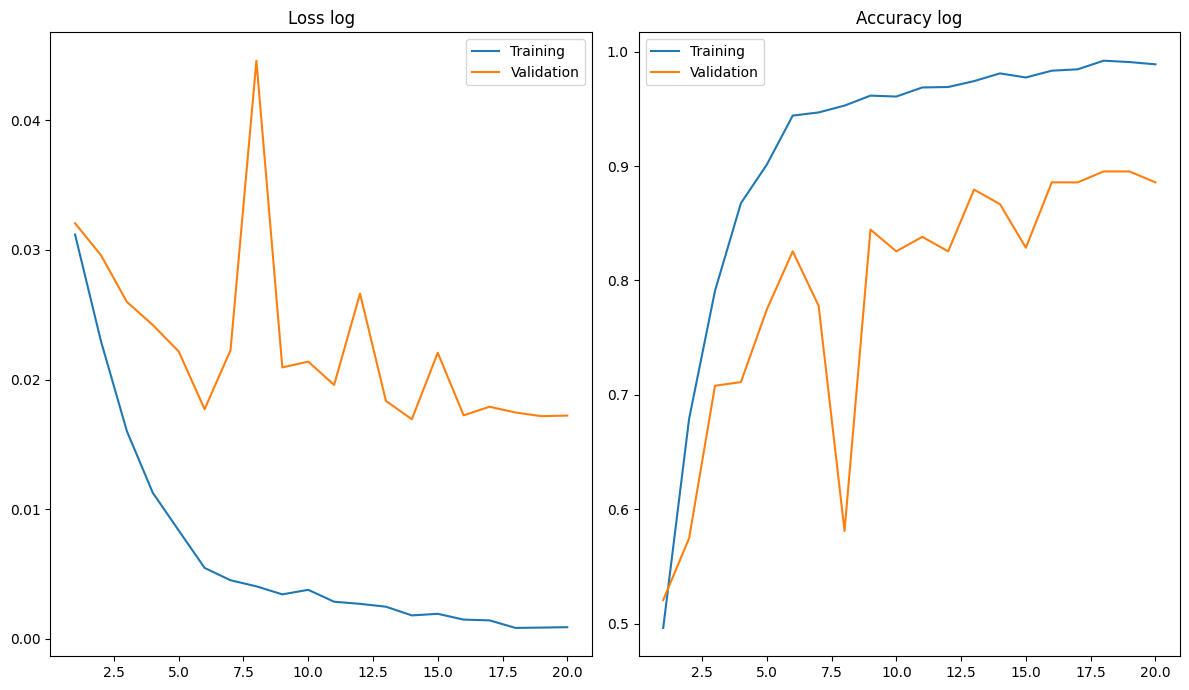

In [23]:
epochs = list(range(1, EPOCHS+1))
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 7))
axes[0].plot(epochs, train_loss)
axes[0].plot(epochs, val_loss)
axes[0].legend(["Training", "Validation"])
axes[0].set_title("Loss log")

axes[1].plot(epochs, train_acc)
axes[1].plot(epochs, val_acc)
axes[1].legend(["Training", "Validation"])
axes[1].set_title("Accuracy log")

plt.tight_layout()
plt.show()

In [24]:
def predict(x):
    img = Image.open(x).convert("RGB")
    img = transform(np.array(img))
    img = img.view(1, 3, 224, 224)
    best_model.eval()
    with torch.no_grad():
        if torch.cuda.is_available():
            img = img.cuda()

        out = best_model(img)

        return out.argmax(1).item()

In [25]:
pred = []
truth = []

for i in range(test.shape[0]):
    pred += [predict(test.iloc[i, 0])]
    truth += [test.iloc[i, 1]]

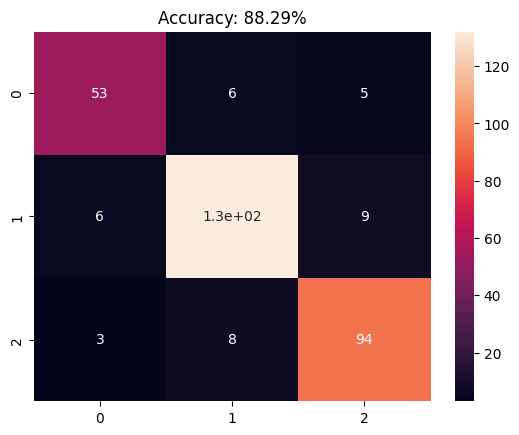

In [26]:
score = accuracy_score(truth, pred)
report = classification_report(truth, pred)
cm = confusion_matrix(truth, pred)
sns.heatmap(cm, annot=True)
plt.title("Accuracy: {}%".format(round(score*100, 2)))
plt.show()

In [27]:
print(report)

              precision    recall  f1-score   support

           0       0.85      0.83      0.84        64
           1       0.90      0.90      0.90       147
           2       0.87      0.90      0.88       105

    accuracy                           0.88       316
   macro avg       0.88      0.87      0.87       316
weighted avg       0.88      0.88      0.88       316



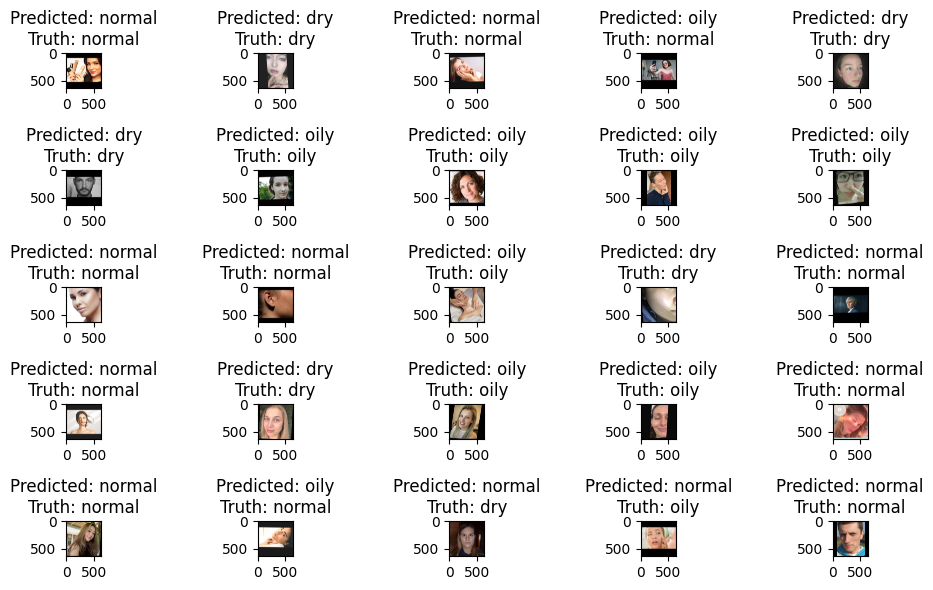

In [28]:
fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(10, 6))
index = 0
for i in range(5):
    for j in range(5):
        img = test.iloc[index, 0]
        img = Image.open(img).convert("RGB")
        axes[i][j].imshow(img)
        axes[i][j].set_title("Predicted: {}\nTruth: {}".format(index_label[pred[index]], index_label[truth[index]]))
        index += 1

plt.tight_layout()
plt.show()

In [33]:
torch.save(best_model.state_dict(), 'skin_type_efficientnetb0_acc88.pt')
print("Final best model has been saved successfully.")

Final best model has been saved successfully.


In [ ]:
# for images, labels in train_dl:
#     print(images)
#     print("Image batch shape:", images.shape)
#     print("Label batch shape:", labels.shape)
#     print("First label in batch:", labels[0])
#     break  # Remove this if you want to see all batches


In [30]:
# let's predict it on custom image

In [40]:
from PIL import Image
import torch

def predict_custom_image(image_path, model, transform, device):
    # 1. Load and convert image to RGB
    img = Image.open(image_path).convert("RGB")

    img_array = np.array(img)
    # 2. Apply transformations
    img_t = transform(img_array)

    # 3. Add batch dimension and move to device
    batch_t = img_t.unsqueeze(0).to(device)

    # 4. Perform inference
    model.eval()
    with torch.no_grad():
        output = model(batch_t)

        # 5. Get the predicted class index
        prediction = torch.argmax(output, dim=1).item()

    # Map index back to label name
    label_name = index_label[prediction]
    return label_name

# Example Usage:
my_image = "/content/drive/MyDrive/skin-care/oily-dry-and-normal-skin-types-dataset/Oily-Dry-Skin-Types/Custom-images/custom4.jpg"
result = predict_custom_image(my_image, best_model, transform, device)
print(f"The predicted skin type is: {result}")

The predicted skin type is: oily
